### **IDENTIFYING THE BEST CLASSIFIER**

#### **Why Balanced Accuracy and Matthews Correlation Coefficient are better than F1 score for imbalanced datasets ?**
♦ F1 score may be misleading for heavily imbalanced datasets as it's biased towards the majority class due to equal weighting of precision and recall, regardless of class balance. Thus, a high F1 score does not necessarily indicate good performance on the minority class.

♦ F1 score is insensitive to misclassified true negatives and prioritizes positive instances more as both precision and recall are calculated based on the positive instances. When working on a heavily imbalanced dataset where positives are as important as the negatives, Balanced Accuracy does much better than F1 score because balanced accuracy shows a fast decrease when there is a decrease in the correct predictions of true negatives.

♦ Matthew’s correlation coefficient takes into account all four categories of confusion matrix and scores high only if high percentage of both negative and positive instances are classified correctly, regardless of class balance or imbalance. It's unbiased towards any class and hence suitable for heavily imbalanced datasets.

♦ Confusion matrix will enable the researcher to compare the performance on the minority classes for testing the hypothesis of this research.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from pathlib import Path
import tensorflow as tf
from random import randint
from tensorflow import keras
import tensorflow_addons as tfa
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from keras.utils.vis_utils import plot_model
from tensorflow.keras import Sequential, Input
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import Conv2D, Flatten
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef as MCC
from distutils.dir_util import copy_tree, remove_tree
from sklearn.metrics import balanced_accuracy_score as BAS
from tensorflow.keras.applications.resnet50 import ResNet50 
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.densenet import DenseNet169
from tensorflow.keras.applications.inception_v3 import InceptionV3
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.efficientnet import EfficientNetB3
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator as IDG
from tensorflow.keras.layers import SeparableConv2D, BatchNormalization, MaxPool2D, GlobalAveragePooling2D

In [2]:
tf.random.set_seed(5638)
random.seed(5638)

In [3]:
EPOCHS = 100
BATCH_SIZE = 32
IMG_SIZE = 128
IMAGE_SIZE = [128, 128]
DIM = (IMG_SIZE, IMG_SIZE)

In [5]:
train_dir = Path('/kaggle/input/kaggle-alzheimers-dataset/Kaggle Alzheimers Dataset/train/')

# Get filepaths and labels
filepaths = list(train_dir.glob(r'**/*.jpg'))
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

# Concatenate filepaths and labels
train_df = pd.concat([filepaths, labels], axis=1)

# Shuffle the DataFrame and reset index
train_df = train_df.sample(frac=1).reset_index(drop = True)

# Show the result
train_df.head(3)

,Filepath,Label
0,Kaggle Alzheimers Dataset\train\NoImpairment\1...,NoImpairment
1,Kaggle Alzheimers Dataset\train\VeryMildImpair...,VeryMildImpairment
2,Kaggle Alzheimers Dataset\train\VeryMildImpair...,VeryMildImpairment


In [6]:
test_dir = Path('/kaggle/input/kaggle-alzheimers-dataset/Kaggle Alzheimers Dataset/test/')

# Get filepaths and labels
filepaths = list(test_dir.glob(r'**/*.jpg'))
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

# Concatenate filepaths and labels
test_df = pd.concat([filepaths, labels], axis=1)

# Shuffle the DataFrame and reset index
test_df = test_df.sample(frac=1).reset_index(drop = True)

# Show the result
test_df.head(3)

,Filepath,Label
0,Kaggle Alzheimers Dataset\test\NoImpairment\28...,NoImpairment
1,Kaggle Alzheimers Dataset\test\MildImpairment\...,MildImpairment
2,Kaggle Alzheimers Dataset\test\NoImpairment\9 ...,NoImpairment


In [7]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1.0/255.0)

test_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1.0/255.0)

train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(128,128),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    seed = 5638,
    shuffle=False
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(128, 128),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    seed = 5638,
    shuffle=False
)

CLASSES = list(test_images.class_indices.keys())

Found 5121 validated image filenames belonging to 4 classes.
Found 1279 validated image filenames belonging to 4 classes.


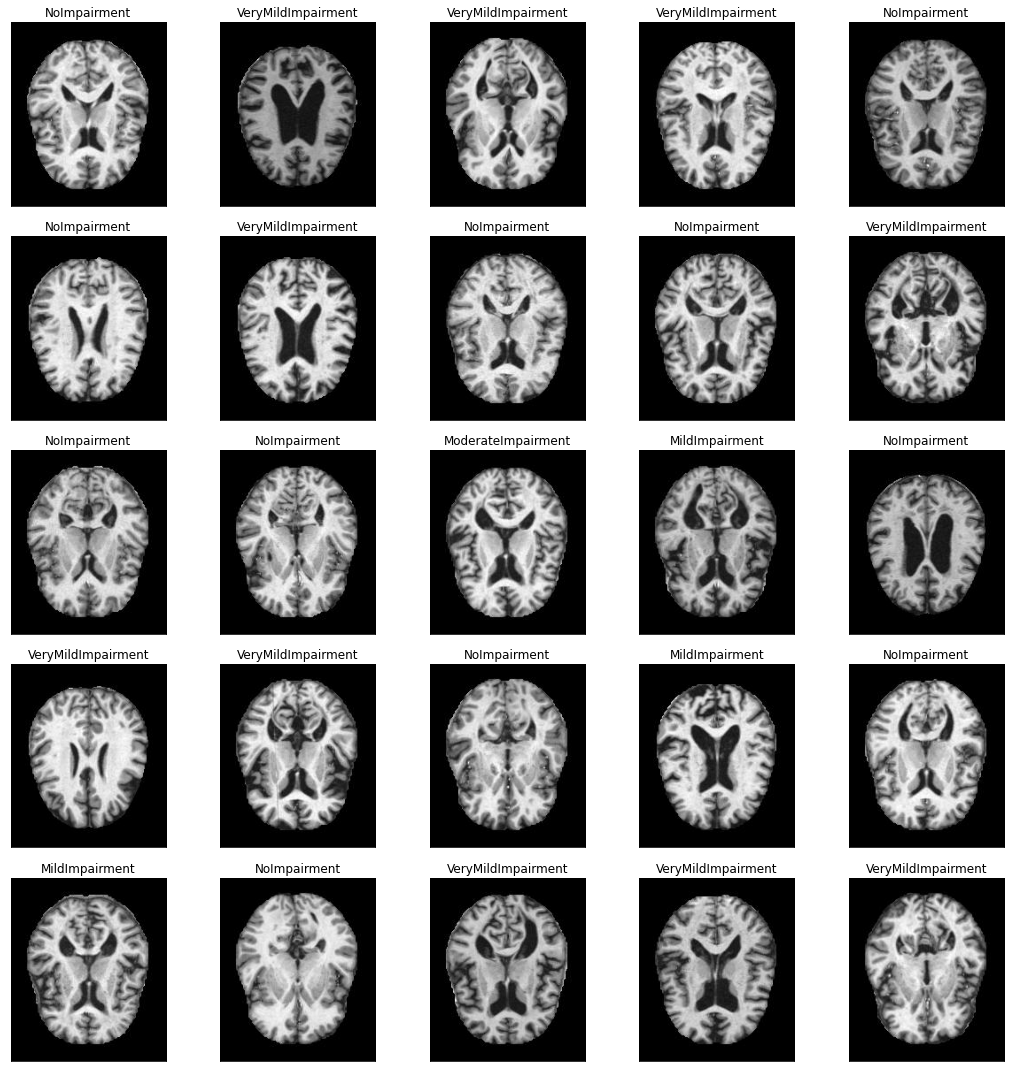

In [ ]:
# Display 20 picture of the dataset with their labels
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(15, 15),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(test_df.Filepath[i]), cmap = 'gray')
    ax.set_title(test_df.Label[i])
plt.tight_layout()
plt.show()

### **DenseNet169**

In [10]:
densenet = DenseNet169(input_shape=(128,128,3), include_top=False, weights='imagenet')    
for layer in densenet.layers:
    layer.trainable=False
densenet_model=Sequential()
densenet_model.add(densenet)
densenet_model.add(Flatten())
densenet_model.add(Dense(4,activation='softmax'))
densenet_model.summary()
OPT = tf.keras.optimizers.Adam(learning_rate=0.001)
METRICS = [tf.keras.metrics.CategoricalAccuracy(name='acc'),tf.keras.metrics.AUC(name='auc'),  tfa.metrics.F1Score(num_classes=4)]
densenet_model.compile(optimizer='adam',loss=tf.losses.CategoricalCrossentropy(),metrics=METRICS)
earlystopping = EarlyStopping(monitor = 'val_loss', mode = 'min', patience = 10, verbose = 1)
filepath = './best_weights.hdf5'
checkpoint = ModelCheckpoint(filepath, monitor = 'val_loss', mode='min', save_best_only=True, verbose = 1)
callback_list = [earlystopping, checkpoint]
#Fit the training data to the model and validate it using the validation data
densenet_history = densenet_model.fit(train_images,validation_data=test_images, callbacks=callback_list, epochs=EPOCHS)

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
densenet169 (Functional)     (None, 4, 4, 1664)        12642880  
_________________________________________________________________
flatten_1 (Flatten)          (None, 26624)             0         
_________________________________________________________________
dense_1 (Dense)              (None, 4)                 106500    
Total params: 12,749,380
Trainable params: 106,500
Non-trainable params: 12,642,880
_________________________________________________________________


2023-01-28 19:30:55.508684: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/100


2023-01-28 19:31:04.057856: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8005


161/161 [==============================] - 67s 330ms/step - loss: 1.5153 - acc: 0.5542 - auc: 0.8102 - f1_score: 0.4222 - val_loss: 1.4419 - val_acc: 0.5481 - val_auc: 0.8434 - val_f1_score: 0.4146

Epoch 00001: val_loss improved from inf to 1.44192, saving model to ./best_weights.hdf5
Epoch 2/100
161/161 [==============================] - 12s 73ms/step - loss: 0.8280 - acc: 0.6719 - auc: 0.8957 - f1_score: 0.6493 - val_loss: 1.1962 - val_acc: 0.6568 - val_auc: 0.8620 - val_f1_score: 0.6848

Epoch 00002: val_loss improved from 1.44192 to 1.19616, saving model to ./best_weights.hdf5
Epoch 3/100
161/161 [==============================] - 12s 71ms/step - loss: 0.7306 - acc: 0.7053 - auc: 0.9183 - f1_score: 0.7039 - val_loss: 0.5879 - val_acc: 0.7498 - val_auc: 0.9377 - val_f1_score: 0.7494

Epoch 00003: val_loss improved from 1.19616 to 0.58791, saving model to ./best_weights.hdf5
Epoch 4/100
161/161 [==============================] - 12s 72ms/step - loss: 0.5130 - acc: 0.7875 - auc: 0.95

In [9]:
test_scores = densenet_model.evaluate(test_images)
print("Testing Accuracy: %.2f%%"%(test_scores[1] * 100))
pred_labels = densenet_model.predict(test_images)

def roundoff(arr):
    """To round off according to the argmax of each predicted label array."""
    arr[np.argwhere(arr != arr.max())] = 0
    arr[np.argwhere(arr == arr.max())] = 1
    return arr

for labels in pred_labels:
    labels = roundoff(labels)
    
pred = np.argmax(pred_labels,axis=1)

print(classification_report(test_images.classes,pred,target_names=CLASSES))

40/40 [==============================] - 69s 2s/step - loss: 0.5959 - acc: 0.7928 - auc: 0.9534 - f1_score: 0.8279
Testing Accuracy: 79.28%
40/40 [==============================] - 66s 2s/step
                    precision    recall  f1-score   support

    MildImpairment       0.79      0.77      0.78       179
ModerateImpairment       1.00      1.00      1.00        12
      NoImpairment       0.75      0.97      0.84       640
VeryMildImpairment       0.92      0.55      0.69       448

          accuracy                           0.79      1279
         macro avg       0.87      0.82      0.83      1279
      weighted avg       0.82      0.79      0.78      1279



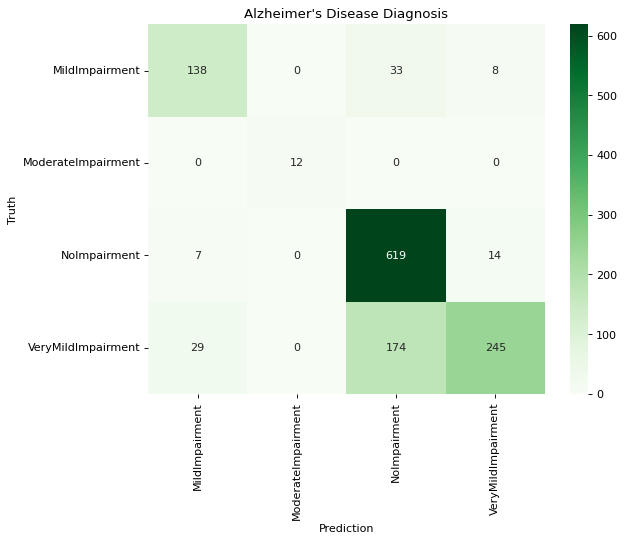

In [10]:
# Plot the confusion matrix to understand the classification in detail

test_ls, pred_ls = test_images.classes,pred
conf_arr = confusion_matrix(test_ls, pred_ls)

plt.figure(figsize=(8, 6), dpi=80, facecolor='w', edgecolor='k')

ax = sns.heatmap(conf_arr, cmap='Greens', annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES)

plt.title('Alzheimer\'s Disease Diagnosis')
plt.xlabel('Prediction')
plt.ylabel('Truth')
plt.show(ax)

In [11]:
#Printing some other classification metrics
print("Balanced Accuracy Score: {} %".format(round(BAS(test_ls, pred_ls) * 100, 2)))
print("Matthew's Correlation Coefficient: {} %".format(round(MCC(test_ls, pred_ls) * 100, 2)))

Balanced Accuracy Score: 82.13 %
Matthew's Correlation Coefficient: 67.11 %


In [ ]:
densenet_model.save('densenet169_model_(82.13%).h5')

### **InceptionV3**

In [11]:
inceptionv3 = InceptionV3(input_shape=(128,128,3), include_top=False, weights='imagenet')    
for layer in inceptionv3.layers:
    layer.trainable=False
inception_model=Sequential()
inception_model.add(inceptionv3)
inception_model.add(Flatten())
inception_model.add(Dense(4,activation='softmax'))
inception_model.summary()
OPT = tf.keras.optimizers.Adam(learning_rate=0.001)
METRICS = [tf.keras.metrics.CategoricalAccuracy(name='acc'),tf.keras.metrics.AUC(name='auc'),tfa.metrics.F1Score(num_classes=4)]
inception_model.compile(optimizer='adam',loss=tf.losses.CategoricalCrossentropy(),metrics=METRICS)
earlystopping = EarlyStopping(monitor = 'val_loss', mode = 'min', patience = 10, verbose = 1)
filepath = './best_weights.hdf5'
checkpoint = ModelCheckpoint(filepath, monitor = 'val_loss', mode='min', save_best_only=True,verbose = 1) 
callback_list = [earlystopping, checkpoint]  
#Fit the training data to the model and validate it using the validation data
inception_history = inception_model.fit(train_images,validation_data=test_images, callbacks=callback_list, epochs=EPOCHS)

87924736/87910968 [==============================] - 3s 0us/step
Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
inception_v3 (Functional)    (None, 2, 2, 2048)        21802784  
_________________________________________________________________
flatten_2 (Flatten)          (None, 8192)              0         
_________________________________________________________________
dense_2 (Dense)              (None, 4)                 32772     
Total params: 21,835,556
Trainable params: 32,772
Non-trainable params: 21,802,784
_________________________________________________________________
Epoch 1/100
161/161 [==============================] - 17s 80ms/step - loss: 1.7395 - acc: 0.5274 - auc: 0.7964 - f1_score: 0.3592 - val_loss: 1.0594 - val_acc: 0.5747 - val_auc: 0.8406 - val_f1_score: 0.5478

Epoch 00001: val_loss improved from inf to 1.05938, saving model to ./best_weights.hdf5
Epoc

In [13]:
test_scores = inception_model.evaluate(test_images)
print("Testing Accuracy: %.2f%%"%(test_scores[1] * 100))
pred_labels = inception_model.predict(test_images)

def roundoff(arr):
    """To round off according to the argmax of each predicted label array."""
    arr[np.argwhere(arr != arr.max())] = 0
    arr[np.argwhere(arr == arr.max())] = 1
    return arr

for labels in pred_labels:
    labels = roundoff(labels)
    
pred = np.argmax(pred_labels,axis=1)

print(classification_report(test_images.classes,pred,target_names=CLASSES))

40/40 [==============================] - 24s 566ms/step - loss: 1.8356 - acc: 0.6482 - auc: 0.8507 - f1_score: 0.6308
Testing Accuracy: 64.82%
40/40 [==============================] - 27s 599ms/step
                    precision    recall  f1-score   support

    MildImpairment       0.81      0.24      0.37       179
ModerateImpairment       1.00      0.67      0.80        12
      NoImpairment       0.85      0.60      0.70       640
VeryMildImpairment       0.51      0.88      0.65       448

          accuracy                           0.65      1279
         macro avg       0.79      0.60      0.63      1279
      weighted avg       0.73      0.65      0.64      1279



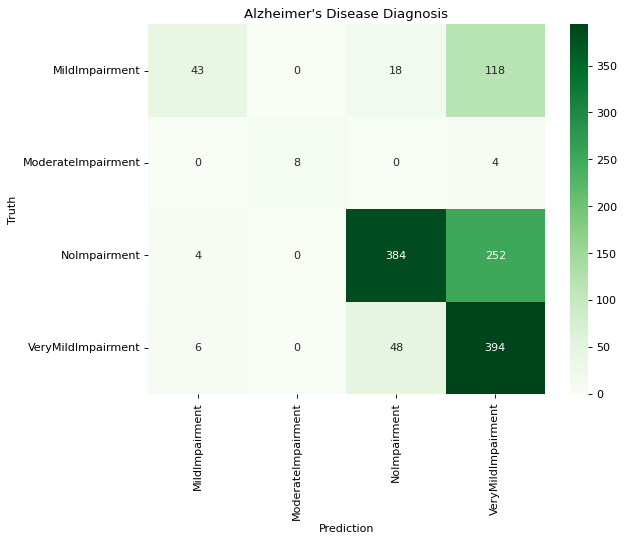

In [14]:
# Plot the confusion matrix to understand the classification in detail

test_ls, pred_ls = test_images.classes,pred
conf_arr = confusion_matrix(test_ls, pred_ls)

plt.figure(figsize=(8, 6), dpi=80, facecolor='w', edgecolor='k')

ax = sns.heatmap(conf_arr, cmap='Greens', annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES)

plt.title('Alzheimer\'s Disease Diagnosis')
plt.xlabel('Prediction')
plt.ylabel('Truth')
plt.show(ax)

In [15]:
#Printing some other classification metrics
print("Balanced Accuracy Score: {} %".format(round(BAS(test_ls, pred_ls) * 100, 2)))
print("Matthew's Correlation Coefficient: {} %".format(round(MCC(test_ls, pred_ls) * 100, 2)))

Balanced Accuracy Score: 59.66 %
Matthew's Correlation Coefficient: 45.81 %


In [ ]:
inception_model.save('inceptionv3_model_(59.66%).h5')

### **ResNet50**

In [13]:
resnet50 = ResNet50(input_shape=(128,128,3), include_top=False, weights='imagenet')    
for layer in resnet50.layers:
    layer.trainable=False
resnet50_model=Sequential()
resnet50_model.add(resnet50)
resnet50_model.add(Flatten())
resnet50_model.add(Dense(4,activation='softmax'))
resnet50_model.summary()
OPT = tf.keras.optimizers.Adam(learning_rate=0.001)
METRICS = [tf.keras.metrics.CategoricalAccuracy(name='acc'),tf.keras.metrics.AUC(name='auc'),tfa.metrics.F1Score(num_classes=4)]
resnet50_model.compile(optimizer='adam',loss=tf.losses.CategoricalCrossentropy(),metrics=METRICS)
earlystopping = EarlyStopping(monitor = 'val_loss', mode = 'min', patience = 10, verbose = 1)
filepath = './best_weights.hdf5'
checkpoint = ModelCheckpoint(filepath, monitor = 'val_loss', mode='min', save_best_only=True, verbose = 1)
callback_list = [earlystopping, checkpoint]
#Fit the training data to the model and validate it using the validation data
resnet_history = resnet50_model.fit(train_images,validation_data=test_images, callbacks=callback_list, epochs=EPOCHS)

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
resnet50 (Functional)        (None, 4, 4, 2048)        23587712  
_________________________________________________________________
flatten_4 (Flatten)          (None, 32768)             0         
_________________________________________________________________
dense_4 (Dense)              (None, 4)                 131076    
Total params: 23,718,788
Trainable params: 131,076
Non-trainable params: 23,587,712
_________________________________________________________________
Epoch 1/100
161/161 [==============================] - 15s 77ms/step - loss: 1.0310 - acc: 0.5106 - auc: 0.8002 - f1_score: 0.2878 - val_loss: 0.9615 - val_acc: 0.5254 - val_auc: 0.8235 - val_f1_score: 0.2886

Epoch 00001: val_loss improved from inf to 0.96145, saving model to ./best_weights.hdf5
Epoch 2/100
161/161 [==============================] - 10s 61ms/step

In [17]:
test_scores = resnet50_model.evaluate(test_images)
print("Testing Accuracy: %.2f%%"%(test_scores[1] * 100))
pred_labels = resnet50_model.predict(test_images)

def roundoff(arr):
    """To round off according to the argmax of each predicted label array."""
    arr[np.argwhere(arr != arr.max())] = 0
    arr[np.argwhere(arr == arr.max())] = 1
    return arr

for labels in pred_labels:
    labels = roundoff(labels)
    
pred = np.argmax(pred_labels,axis=1)

print(classification_report(test_images.classes,pred,target_names=CLASSES))

40/40 [==============================] - 51s 1s/step - loss: 0.6952 - acc: 0.6966 - auc: 0.9103 - f1_score: 0.7028
Testing Accuracy: 69.66%
40/40 [==============================] - 51s 1s/step
                    precision    recall  f1-score   support

    MildImpairment       0.72      0.64      0.68       179
ModerateImpairment       0.75      1.00      0.86        12
      NoImpairment       0.67      0.95      0.78       640
VeryMildImpairment       0.80      0.35      0.49       448

          accuracy                           0.70      1279
         macro avg       0.74      0.74      0.70      1279
      weighted avg       0.72      0.70      0.67      1279



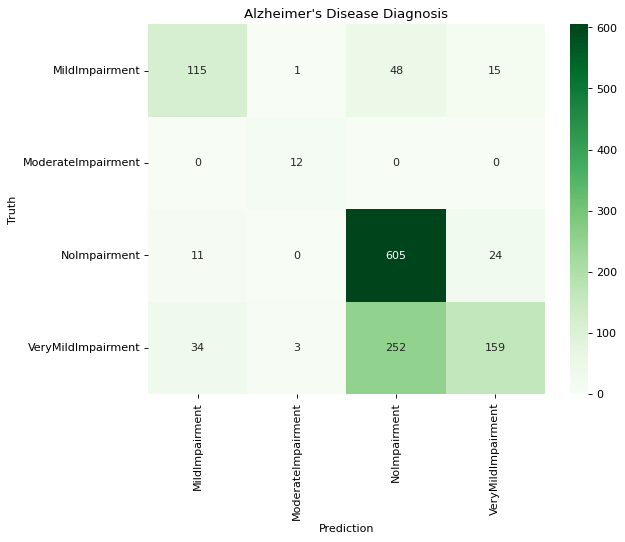

In [18]:
# Plot the confusion matrix to understand the classification in detail

test_ls, pred_ls = test_images.classes,pred
conf_arr = confusion_matrix(test_ls, pred_ls)

plt.figure(figsize=(8, 6), dpi=80, facecolor='w', edgecolor='k')

ax = sns.heatmap(conf_arr, cmap='Greens', annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES)

plt.title('Alzheimer\'s Disease Diagnosis')
plt.xlabel('Prediction')
plt.ylabel('Truth')
plt.show(ax)

In [19]:
#Printing some other classification metrics
print("Balanced Accuracy Score: {} %".format(round(BAS(test_ls, pred_ls) * 100, 2)))
print("Matthew's Correlation Coefficient: {} %".format(round(MCC(test_ls, pred_ls) * 100, 2)))

Balanced Accuracy Score: 73.57 %
Matthew's Correlation Coefficient: 51.25 %


In [ ]:
resnet50_model.save('resnet50_model_(28.31%).h5')

### **Xception**

In [14]:
xception = Xception(input_shape=(128,128,3), include_top=False, weights='imagenet')    
for layer in xception.layers:
    layer.trainable=False
xception_model=Sequential()
xception_model.add(xception)
xception_model.add(Flatten())
xception_model.add(Dense(4,activation='softmax'))
xception_model.summary()
OPT = tf.keras.optimizers.Adam(learning_rate=0.001)
METRICS = [tf.keras.metrics.CategoricalAccuracy(name='acc'),tf.keras.metrics.AUC(name='auc'), tfa.metrics.F1Score(num_classes=4)]
xception_model.compile(optimizer='adam', loss=tf.losses.CategoricalCrossentropy(),metrics=METRICS)
earlystopping = EarlyStopping(monitor = 'val_loss', mode = 'min', patience = 10, verbose = 1)
filepath = './best_weights.hdf5'
checkpoint = ModelCheckpoint(filepath, monitor = 'val_loss', mode='min', save_best_only=True, verbose = 1)
callback_list = [earlystopping, checkpoint]
#Fit the training data to the model and validate it using the validation data
xception_history = xception_model.fit(train_images,validation_data=test_images, callbacks=callback_list, epochs=EPOCHS)

83697664/83683744 [==============================] - 3s 0us/step
Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
xception (Functional)        (None, 4, 4, 2048)        20861480  
_________________________________________________________________
flatten_5 (Flatten)          (None, 32768)             0         
_________________________________________________________________
dense_5 (Dense)              (None, 4)                 131076    
Total params: 20,992,556
Trainable params: 131,076
Non-trainable params: 20,861,480
_________________________________________________________________
Epoch 1/100
161/161 [==============================] - 13s 66ms/step - loss: 1.4078 - acc: 0.5411 - auc: 0.8123 - f1_score: 0.3685 - val_loss: 1.2377 - val_acc: 0.5192 - val_auc: 0.8207 - val_f1_score: 0.3522

Epoch 00001: val_loss improved from inf to 1.23770, saving model to ./best_weights.hdf5
Epo

In [21]:
test_scores = xception_model.evaluate(test_images)
print("Testing Accuracy: %.2f%%"%(test_scores[1] * 100))
pred_labels = xception_model.predict(test_images)

def roundoff(arr):
    """To round off according to the argmax of each predicted label array."""
    arr[np.argwhere(arr != arr.max())] = 0
    arr[np.argwhere(arr == arr.max())] = 1
    return arr

for labels in pred_labels:
    labels = roundoff(labels)
    
pred = np.argmax(pred_labels,axis=1)

print(classification_report(test_images.classes,pred,target_names=CLASSES))

40/40 [==============================] - 51s 1s/step - loss: 0.7603 - acc: 0.7389 - auc: 0.9346 - f1_score: 0.6977
Testing Accuracy: 73.89%
40/40 [==============================] - 54s 1s/step
                    precision    recall  f1-score   support

    MildImpairment       0.89      0.48      0.62       179
ModerateImpairment       0.88      0.58      0.70        12
      NoImpairment       0.71      0.92      0.80       640
VeryMildImpairment       0.76      0.59      0.67       448

          accuracy                           0.74      1279
         macro avg       0.81      0.64      0.70      1279
      weighted avg       0.75      0.74      0.73      1279



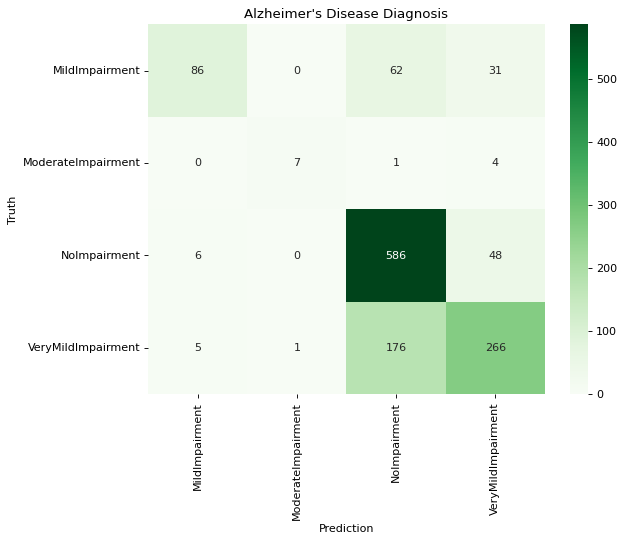

In [22]:
# Plot the confusion matrix to understand the classification in detail

test_ls, pred_ls = test_images.classes,pred
conf_arr = confusion_matrix(test_ls, pred_ls)

plt.figure(figsize=(8, 6), dpi=80, facecolor='w', edgecolor='k')

ax = sns.heatmap(conf_arr, cmap='Greens', annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES)

plt.title('Alzheimer\'s Disease Diagnosis')
plt.xlabel('Prediction')
plt.ylabel('Truth')
plt.show(ax)

In [23]:
#Printing some other classification metrics
print("Balanced Accuracy Score: {} %".format(round(BAS(test_ls, pred_ls) * 100, 2)))
print("Matthew's Correlation Coefficient: {} %".format(round(MCC(test_ls, pred_ls) * 100, 2)))

Balanced Accuracy Score: 64.33 %
Matthew's Correlation Coefficient: 56.02 %


In [ ]:
xception_model.save('xception_model_(64.33%).h5')

### **EfficientNetB3**

In [15]:
efficientnet = EfficientNetB3(input_shape=(128,128,3), include_top=False, weights='imagenet')    
for layer in efficientnet.layers:
    layer.trainable=False
efficientnet_model=Sequential()
efficientnet_model.add(efficientnet)
efficientnet_model.add(Flatten())
efficientnet_model.add(Dense(4,activation='softmax'))
efficientnet_model.summary()
OPT = tf.keras.optimizers.Adam(learning_rate=0.001)
METRICS = [tf.keras.metrics.CategoricalAccuracy(name='acc'), tf.keras.metrics.AUC(name='auc'), tfa.metrics.F1Score(num_classes=4)]
efficientnet_model.compile(optimizer='adam',loss=tf.losses.CategoricalCrossentropy(),metrics=METRICS)
earlystopping = EarlyStopping(monitor = 'val_loss', mode = 'min', patience = 10,verbose = 1)
filepath = './best_weights.hdf5'
checkpoint = ModelCheckpoint(filepath, monitor = 'val_loss', mode='min', save_best_only=True, verbose = 1)
callback_list = [earlystopping, checkpoint]
#Fit the training data to the model and validate it using the validation data
efficientnet_history = efficientnet_model.fit(train_images,validation_data=test_images, callbacks=callback_list, epochs=EPOCHS)

43950080/43941136 [==============================] - 2s 0us/step
Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
efficientnetb3 (Functional)  (None, 4, 4, 1536)        10783535  
_________________________________________________________________
flatten_6 (Flatten)          (None, 24576)             0         
_________________________________________________________________
dense_6 (Dense)              (None, 4)                 98308     
Total params: 10,881,843
Trainable params: 98,308
Non-trainable params: 10,783,535
_________________________________________________________________
Epoch 1/100
161/161 [==============================] - 20s 78ms/step - loss: 1.6042 - acc: 0.4111 - auc: 0.7221 - f1_score: 0.2409 - val_loss: 1.1120 - val_acc: 0.3503 - val_auc: 0.7367 - val_f1_score: 0.1297

Epoch 00001: val_loss improved from inf to 1.11198, saving model to ./best_weights.hdf5
Epoc

In [25]:
test_scores = efficientnet_model.evaluate(test_images)
print("Testing Accuracy: %.2f%%"%(test_scores[1] * 100))
pred_labels = efficientnet_model.predict(test_images)

def roundoff(arr):
    """To round off according to the argmax of each predicted label array."""
    arr[np.argwhere(arr != arr.max())] = 0
    arr[np.argwhere(arr == arr.max())] = 1
    return arr

for labels in pred_labels:
    labels = roundoff(labels)
    
pred = np.argmax(pred_labels,axis=1)

print(classification_report(test_images.classes,pred,target_names=CLASSES))

40/40 [==============================] - 54s 1s/step - loss: 1.2284 - acc: 0.4871 - auc: 0.7261 - f1_score: 0.2478
Testing Accuracy: 48.71%
40/40 [==============================] - 52s 1s/step
                    precision    recall  f1-score   support

    MildImpairment       0.28      0.40      0.33       179
ModerateImpairment       0.00      0.00      0.00        12
      NoImpairment       0.54      0.86      0.66       640
VeryMildImpairment       0.00      0.00      0.00       448

          accuracy                           0.49      1279
         macro avg       0.20      0.31      0.25      1279
      weighted avg       0.31      0.49      0.38      1279



c:\Users\lukec\AppData\Local\Programs\Python\Python310\lib\site-packages\scikit_learn-1.1.2-py3.10-win-amd64.egg\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\lukec\AppData\Local\Programs\Python\Python310\lib\site-packages\scikit_learn-1.1.2-py3.10-win-amd64.egg\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\lukec\AppData\Local\Programs\Python\Python310\lib\site-packages\scikit_learn-1.1.2-py3.10-win-amd64.egg\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set 

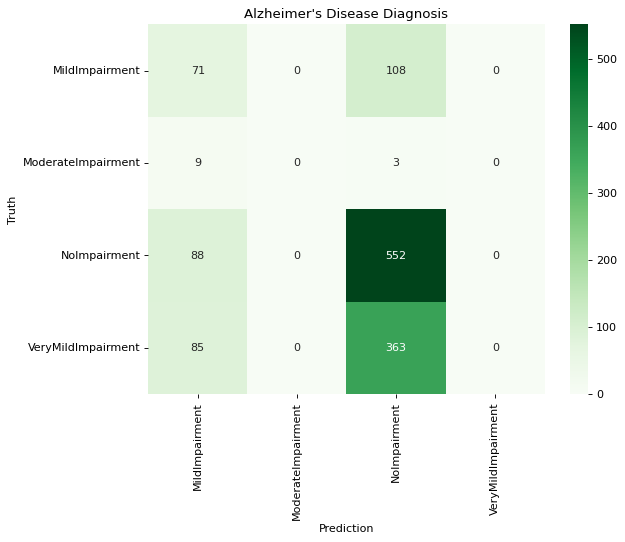

In [26]:
# Plot the confusion matrix to understand the classification in detail

test_ls, pred_ls = test_images.classes,pred
conf_arr = confusion_matrix(test_ls, pred_ls)

plt.figure(figsize=(8, 6), dpi=80, facecolor='w', edgecolor='k')

ax = sns.heatmap(conf_arr, cmap='Greens', annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES)

plt.title('Alzheimer\'s Disease Diagnosis')
plt.xlabel('Prediction')
plt.ylabel('Truth')
plt.show(ax)

In [27]:
#Printing some other classification metrics
print("Balanced Accuracy Score: {} %".format(round(BAS(test_ls, pred_ls) * 100, 2)))
print("Matthew's Correlation Coefficient: {} %".format(round(MCC(test_ls, pred_ls) * 100, 2)))

Balanced Accuracy Score: 31.48 %
Matthew's Correlation Coefficient: 13.21 %


In [ ]:
efficientnet_model.save('efficientnetb3_model_(31.48%).h5')

### **VGG19**

In [37]:
vgg19 = VGG19(input_shape=(128,128,3), include_top=False, weights='imagenet')    
for layer in vgg19.layers:
    layer.trainable=False
vgg19_model=Sequential()
vgg19_model.add(vgg19)
vgg19_model.add(Flatten())
vgg19_model.add(Dense(4,activation='softmax'))
vgg19_model.summary()
OPT = tf.keras.optimizers.Adam(learning_rate=0.001)
METRICS = [tf.keras.metrics.CategoricalAccuracy(name='acc'),tf.keras.metrics.AUC(name='auc'), tfa.metrics.F1Score(num_classes=4)]
vgg19_model.compile(optimizer='adam',loss=tf.losses.CategoricalCrossentropy(), metrics=METRICS)
earlystopping = EarlyStopping(monitor = 'val_loss', mode = 'min', patience = 10, verbose = 1)
filepath = './best_weights.hdf5'                             
checkpoint = ModelCheckpoint(filepath, monitor = 'val_loss', mode='min', save_best_only=True, verbose = 1)
callback_list = [earlystopping, checkpoint]    
#Fit the training data to the model and validate it using the validation data
vgg_history = vgg19_model.fit(train_images,validation_data=test_images, callbacks=callback_list, epochs=EPOCHS)

Model: "sequential_11"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg19 (Functional)           (None, 4, 4, 512)         20024384  
_________________________________________________________________
flatten_14 (Flatten)         (None, 8192)              0         
_________________________________________________________________
dense_23 (Dense)             (None, 4)                 32772     
Total params: 20,057,156
Trainable params: 32,772
Non-trainable params: 20,024,384
_________________________________________________________________
Epoch 1/100
161/161 [==============================] - 10s 59ms/step - loss: 0.9672 - acc: 0.5538 - auc: 0.8276 - f1_score: 0.3273 - val_loss: 0.8437 - val_acc: 0.6106 - val_auc: 0.8688 - val_f1_score: 0.3989

Epoch 00001: val_loss improved from inf to 0.84369, saving model to ./best_weights.hdf5
Epoch 2/100
161/161 [==============================] - 9s 57ms/step 

In [29]:
test_scores = vgg19_model.evaluate(test_images)
print("Testing Accuracy: %.2f%%"%(test_scores[1] * 100))
pred_labels = vgg19_model.predict(test_images)

def roundoff(arr):
    """To round off according to the argmax of each predicted label array."""
    arr[np.argwhere(arr != arr.max())] = 0
    arr[np.argwhere(arr == arr.max())] = 1
    return arr

for labels in pred_labels:
    labels = roundoff(labels)
    
pred = np.argmax(pred_labels,axis=1)

print(classification_report(test_images.classes,pred,target_names=CLASSES))

40/40 [==============================] - 140s 3s/step - loss: 0.5915 - acc: 0.7138 - auc: 0.9344 - f1_score: 0.7523
Testing Accuracy: 71.38%
40/40 [==============================] - 156s 4s/step
                    precision    recall  f1-score   support

    MildImpairment       0.95      0.39      0.55       179
ModerateImpairment       1.00      1.00      1.00        12
      NoImpairment       0.96      0.62      0.75       640
VeryMildImpairment       0.56      0.98      0.71       448

          accuracy                           0.71      1279
         macro avg       0.87      0.74      0.75      1279
      weighted avg       0.82      0.71      0.71      1279



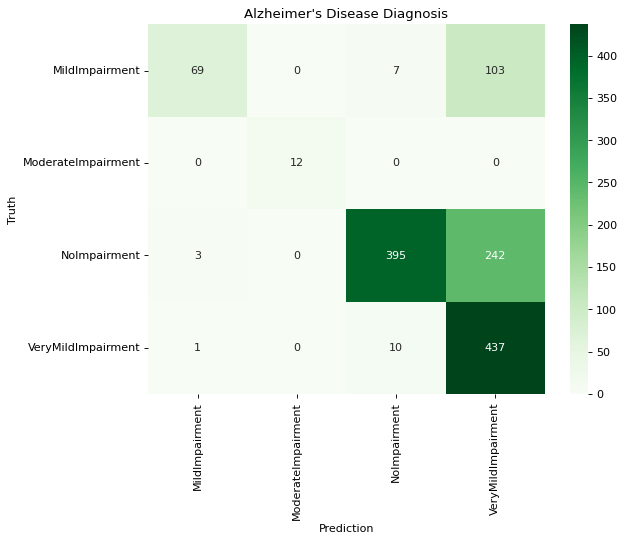

In [32]:
# Plot the confusion matrix to understand the classification in detail

test_ls, pred_ls = test_images.classes,pred
conf_arr = confusion_matrix(test_ls, pred_ls)

plt.figure(figsize=(8, 6), dpi=80, facecolor='w', edgecolor='k')

ax = sns.heatmap(conf_arr, cmap='Greens', annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES)

plt.title('Alzheimer\'s Disease Diagnosis')
plt.xlabel('Prediction')
plt.ylabel('Truth')
plt.show(ax)

In [33]:
#Printing some other classification metrics
print("Balanced Accuracy Score: {} %".format(round(BAS(test_ls, pred_ls) * 100, 2)))
print("Matthew's Correlation Coefficient: {} %".format(round(MCC(test_ls, pred_ls) * 100, 2)))

Balanced Accuracy Score: 74.45 %
Matthew's Correlation Coefficient: 58.85 %


In [ ]:
vgg19_model.save('vgg19_model_(74.45%).h5')

### **Custom CNN**

In [28]:
custom_model = Sequential([
    Input(shape=(*IMAGE_SIZE, 3)),
    Conv2D(16, 3, activation='relu', padding='same'),
    Conv2D(16, 3, activation='relu', padding='same'),
    MaxPool2D(),
    Conv2D(32, 3, activation='relu', padding='same'),
    Conv2D(32, 3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(),
    Conv2D(64, 3, activation='relu', padding='same'),
    Conv2D(64, 3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(),
    Conv2D(128, 3, activation='relu', padding='same'),
    Conv2D(128, 3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(),
    Conv2D(256, 3, activation='relu', padding='same'),
    Conv2D(256, 3, activation='relu', padding='same', name = 'last_conv_layer'),
    BatchNormalization(),
    MaxPool2D(),
    Flatten(),
    Dropout(0.2),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.7),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(4, activation='softmax')        
], name = "cnn_model")

custom_model.summary()

OPT = tf.keras.optimizers.Adam(learning_rate=0.001)
METRICS = [tf.keras.metrics.CategoricalAccuracy(name='acc'), tf.keras.metrics.AUC(name='auc'), tfa.metrics.F1Score(num_classes=4)]
custom_model.compile(optimizer='adam',loss=tf.losses.CategoricalCrossentropy(),metrics=METRICS)
earlystopping = EarlyStopping(monitor = 'val_loss', mode = 'min', patience = 10, verbose = 1)
filepath = './best_weights.hdf5'
checkpoint = ModelCheckpoint(filepath, monitor = 'val_loss', mode='min', save_best_only=True, verbose = 1)
callback_list = [earlystopping, checkpoint]
#Fit the training data to the model and validate it using the validation data
custom_model_history = custom_model.fit(train_images,validation_data=test_images, callbacks=callback_list, epochs=EPOCHS)

Model: "cnn_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_116 (Conv2D)          (None, 128, 128, 16)      448       
_________________________________________________________________
conv2d_117 (Conv2D)          (None, 128, 128, 16)      2320      
_________________________________________________________________
max_pooling2d_14 (MaxPooling (None, 64, 64, 16)        0         
_________________________________________________________________
conv2d_118 (Conv2D)          (None, 64, 64, 32)        4640      
_________________________________________________________________
conv2d_119 (Conv2D)          (None, 64, 64, 32)        9248      
_________________________________________________________________
batch_normalization_112 (Bat (None, 64, 64, 32)        128       
_________________________________________________________________
max_pooling2d_15 (MaxPooling (None, 32, 32, 32)        0 

In [35]:
test_scores = custom_model.evaluate(test_images)
print("Testing Accuracy: %.2f%%"%(test_scores[1] * 100))
pred_labels = custom_model.predict(test_images)

def roundoff(arr):
    """To round off according to the argmax of each predicted label array."""
    arr[np.argwhere(arr != arr.max())] = 0
    arr[np.argwhere(arr == arr.max())] = 1
    return arr

for labels in pred_labels:
    labels = roundoff(labels)
    
pred = np.argmax(pred_labels,axis=1)

print(classification_report(test_images.classes,pred,target_names=CLASSES))

40/40 [==============================] - 10s 239ms/step - loss: 0.4526 - acc: 0.8913 - auc: 0.9710 - f1_score: 0.8802
Testing Accuracy: 89.13%
40/40 [==============================] - 13s 321ms/step
                    precision    recall  f1-score   support

    MildImpairment       1.00      0.65      0.79       179
ModerateImpairment       0.86      1.00      0.92        12
      NoImpairment       0.83      1.00      0.91       640
VeryMildImpairment       0.99      0.83      0.90       448

          accuracy                           0.89      1279
         macro avg       0.92      0.87      0.88      1279
      weighted avg       0.91      0.89      0.89      1279



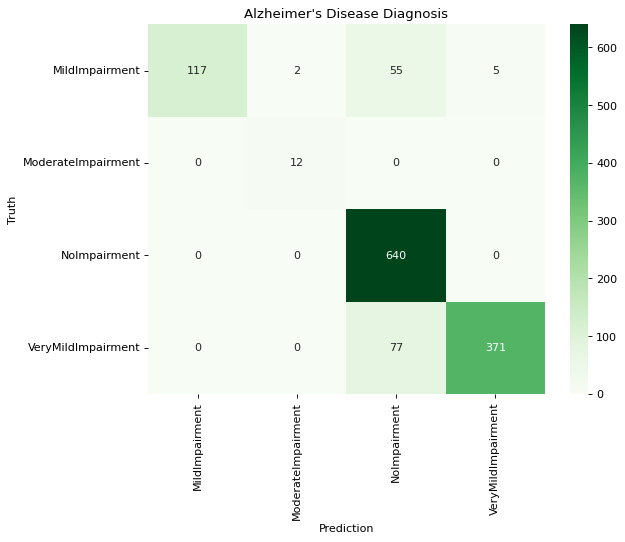

In [36]:
# Plot the confusion matrix to understand the classification in detail

test_ls, pred_ls = test_images.classes,pred
conf_arr = confusion_matrix(test_ls, pred_ls)

plt.figure(figsize=(8, 6), dpi=80, facecolor='w', edgecolor='k')

ax = sns.heatmap(conf_arr, cmap='Greens', annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES)

plt.title('Alzheimer\'s Disease Diagnosis')
plt.xlabel('Prediction')
plt.ylabel('Truth')
plt.show(ax)

In [37]:
#Printing some other classification metrics
print("Balanced Accuracy Score: {} %".format(round(BAS(test_ls, pred_ls) * 100, 2)))
print("Matthew's Correlation Coefficient: {} %".format(round(MCC(test_ls, pred_ls) * 100, 2)))

Balanced Accuracy Score: 87.04 %
Matthew's Correlation Coefficient: 82.61 %


In [111]:
custom_model.save('custom_cnn_(87.04%).h5')